# VAE V5 Final — Complete CASIA Faculty Demo

Loads `VAE_V5_FINAL.pth` and shows architecture, verified 80-epoch training, hybrid reconstruction/KL losses, canonical test results, reconstructions, exploratory ROC analysis, and synthetic sampling. No retraining.

In [1]:
from pathlib import Path
import json, random, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from IPython.display import display
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
candidates=[Path.cwd(),*Path.cwd().parents,Path('/content/Digital-Evidence-GenAI'),Path('/content/AI-Digital-Evidence-Intelligence-Platform')]
PROJECT_ROOT=next((p.resolve() for p in candidates if (p/'src').is_dir() and (p/'checkpoints').is_dir()),None)
if PROJECT_ROOT is None: raise FileNotFoundError('Run inside the project repository.')
sys.path.insert(0,str(PROJECT_ROOT/'src'))
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Project:',PROJECT_ROOT)
print('Device:',torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('LOAD-ONLY DEMO: models will not be retrained.')

Project: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence
Device: CPU
LOAD-ONLY DEMO: models will not be retrained.


## 1. Dataset and fixed splits

The final checkpoint used mixed CASIA reconstruction training. Labels remain analysis metadata.

In [2]:
frames={name:pd.read_csv(PROJECT_ROOT/'data'/'splits'/f'{name}.csv') for name in ('train','validation','test')}
rows=[]
for name,frame in frames.items(): rows.append({'split':name.title(),'total':len(frame),'authentic':int((frame.label==0).sum()),'tampered':int((frame.label==1).sum())})
display(pd.DataFrame(rows)); print('Total:',sum(r['total'] for r in rows),'| seed: 42')
print('Masks are excluded; labels are metadata, not reconstruction targets.')

,split,total,authentic,tampered
0,Train,8830,5244,3586
1,Validation,1892,1124,768
2,Test,1892,1123,769


Total: 12614 | seed: 42
Masks are excluded; labels are metadata, not reconstruction targets.


## 2. Architecture and checkpoint

Residual/GroupNorm/SiLU encoder, 256-dimensional `mu` and `logvar`, reparameterization `z=mu+sigma×epsilon`, skip-connected decoder, Sigmoid RGB output.

In [3]:
from vae import VAEV5
CHECKPOINT=PROJECT_ROOT/'checkpoints'/'VAE_V5_FINAL.pth'; ckpt=torch.load(CHECKPOINT,map_location=DEVICE,weights_only=True)
model=VAEV5(int(ckpt.get('latent_dim',256))).to(DEVICE); model.load_state_dict(ckpt['model_state_dict'],strict=True); model.eval()
print('Checkpoint:',CHECKPOINT); print('Epoch:',ckpt.get('epoch')); print('Validation MSE/PSNR/KL:',ckpt.get('val_mse'),ckpt.get('val_psnr'),ckpt.get('val_kl')); print('Beta/L1 weight:',ckpt.get('beta'),ckpt.get('l1_weight')); print('Parameters:',f'{sum(p.numel() for p in model.parameters()):,}')

Checkpoint: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence\checkpoints\VAE_V5_FINAL.pth
Epoch: 79
Validation MSE/PSNR/KL: 0.0009786994070952746 30.093506747804902 0.008678044643386978
Beta/L1 weight: 0.0003 0.5
Parameters: 17,599,971


## 3. Loss and KL warm-up

`Reconstruction = 0.5×MSE + 0.5×L1`; `Total = Reconstruction + beta×KL`. Beta increases from 0.00005 to 0.00030 over 20 epochs. Lower KL does not automatically mean better reconstruction.

## 4. Verified training history

,epoch,train_mse,validation_mse,validation_psnr,validation_kl,beta,learning_rate
75,76,0.00057,0.00099,30.04,0.0100,0.0003,0.00005
76,77,0.00057,0.00099,30.04,0.0104,0.0003,0.00005
77,78,0.00057,0.00100,30.00,0.0091,0.0003,0.00005
78,79,0.00056,0.00098,30.09,0.0087,0.0003,0.00005
79,80,0.00057,0.00099,30.04,0.0095,0.0003,0.00005


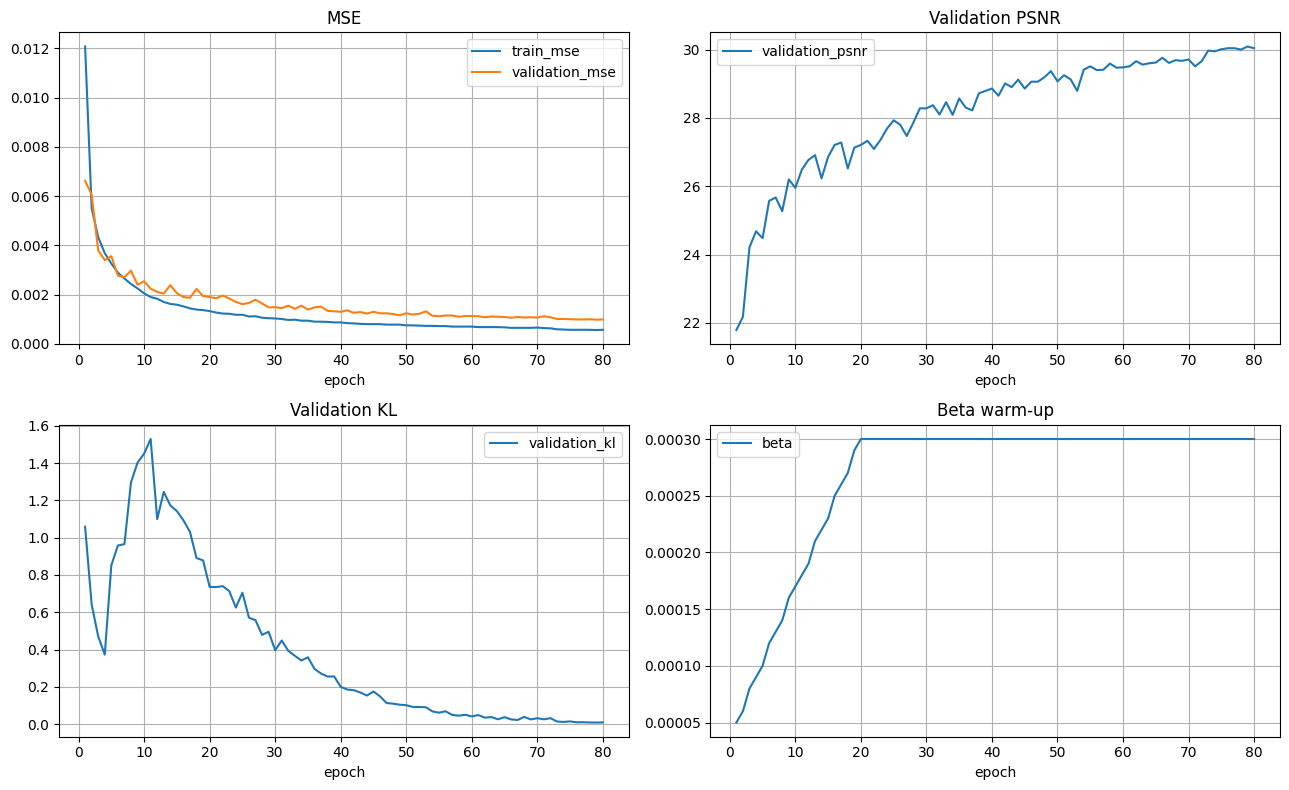

Epochs: 80 | Best epoch: 79 | Best MSE: 0.00098 | PSNR: 30.09


In [4]:
history=pd.read_csv(PROJECT_ROOT/'results'/'vae_v5_final_training_history.csv'); display(history.tail())
fig,axes=plt.subplots(2,2,figsize=(13,8)); history.plot(x='epoch',y=['train_mse','validation_mse'],ax=axes[0,0],grid=True,title='MSE'); history.plot(x='epoch',y='validation_psnr',ax=axes[0,1],grid=True,title='Validation PSNR'); history.plot(x='epoch',y='validation_kl',ax=axes[1,0],grid=True,title='Validation KL'); history.plot(x='epoch',y='beta',ax=axes[1,1],grid=True,title='Beta warm-up'); plt.tight_layout(); plt.show()
best=history.loc[history.validation_mse.idxmin()]; print('Epochs:',len(history),'| Best epoch:',int(best.epoch),'| Best MSE:',best.validation_mse,'| PSNR:',best.validation_psnr)

## 5. Complete canonical test metrics

In [5]:
metrics=json.loads((PROJECT_ROOT/'results'/'vae_v5_final_test_metrics.json').read_text()); display(pd.DataFrame([{'group':'Overall',**metrics['overall']},{'group':'Authentic',**metrics['authentic']},{'group':'Tampered',**metrics['tampered']}])[['group','count','mse_mean','mse_std','psnr_mean','ssim_mean','kl_loss_mean','total_loss_mean']]); print('ROC-AUC:',metrics['roc_auc']); print('FID:',metrics['fid'] if metrics['fid'] is not None else 'N/A')

,group,count,mse_mean,mse_std,psnr_mean,ssim_mean,kl_loss_mean,total_loss_mean
0,Overall,1892,0.000700,0.001121,32.953456,0.961139,0.012930,0.008900
1,Authentic,1123,0.000709,0.001251,33.004891,0.962650,0.018167,0.008908
2,Tampered,769,0.000687,0.000896,32.878345,0.958932,0.005281,0.008887


ROC-AUC: {'mse': 0.5153817739266571, 'ssim_error': 0.5705580329486202, 'interpretation': 'Exploratory ranking only; reconstruction error is not a calibrated tampering probability or standalone detector.'}
FID: N/A


## 6. Fresh reconstruction examples

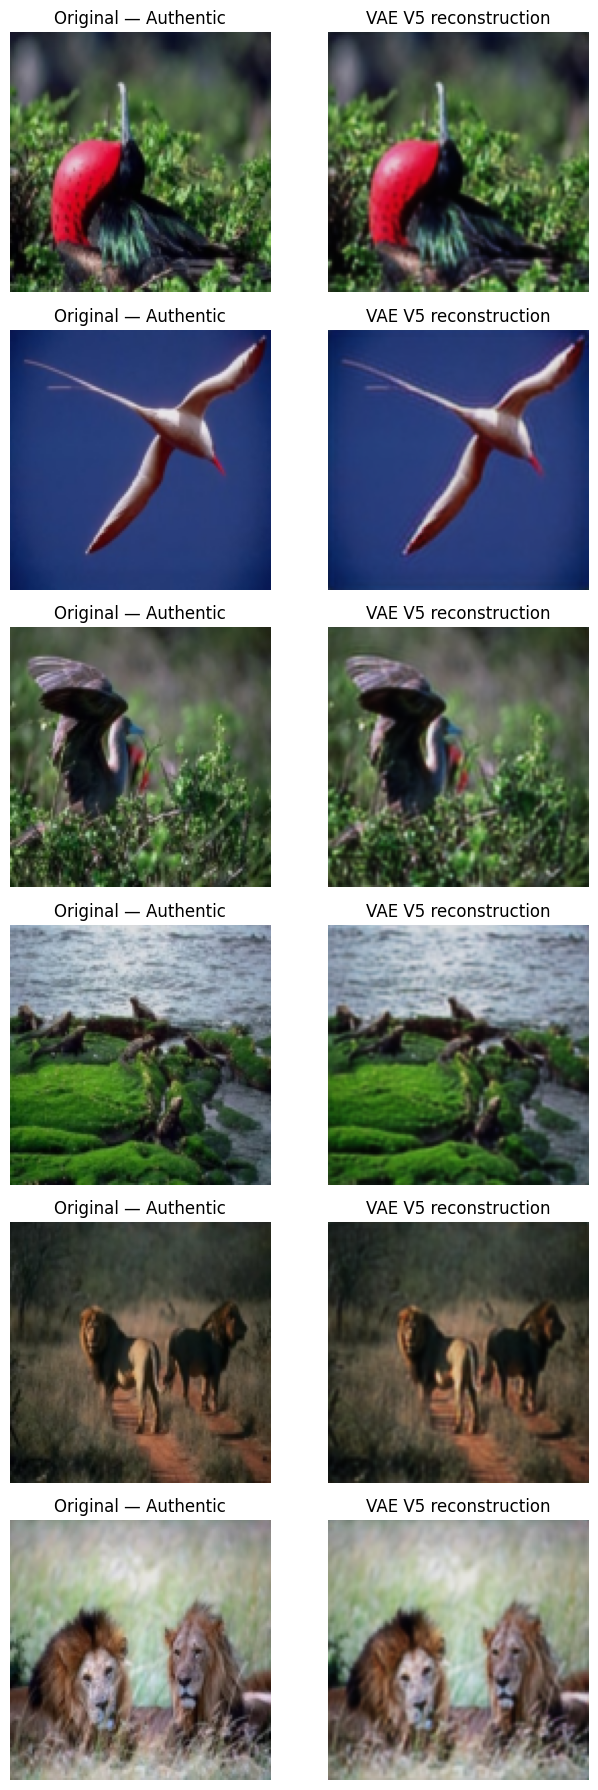

Input/mu/logvar/output: (6, 3, 128, 128) (6, 256) (6, 256) (6, 3, 128, 128)


In [6]:
from ae_dataset import AutoencoderImageDataset
from torch.utils.data import DataLoader
batch=next(iter(DataLoader(AutoencoderImageDataset(PROJECT_ROOT/'data'/'splits'/'test.csv',128),batch_size=6,shuffle=False,num_workers=0))); x=batch['image'].to(DEVICE)
with torch.no_grad(): y,mu,logvar=model.reconstruct(x,deterministic=True)
fig,axes=plt.subplots(6,2,figsize=(7,18))
for i in range(6):
 label='Authentic' if int(batch['label'][i])==0 else 'Tampered'; axes[i,0].imshow(x[i].cpu().permute(1,2,0)); axes[i,0].set_title('Original — '+label); axes[i,1].imshow(y[i].cpu().permute(1,2,0).clamp(0,1)); axes[i,1].set_title('VAE V5 reconstruction')
 for ax in axes[i]: ax.axis('off')
plt.tight_layout(); plt.show(); print('Input/mu/logvar/output:',tuple(x.shape),tuple(mu.shape),tuple(logvar.shape),tuple(y.shape))

## 7. Forensic reconstruction analysis

ROC-AUC is exploratory—not a calibrated tampering probability or standalone detector.

mse                           psnr                       \
                mean    median       std       mean     median       std   
class_name                                                                 
authentic   0.000709  0.000506  0.001252  33.004891  32.959702  3.244092   
tampered    0.000687  0.000523  0.000897  32.878345  32.814529  3.049145   

                ssim                      
                mean    median       std  
class_name                                
authentic   0.962650  0.965671  0.018068  
tampered    0.958932  0.962115  0.018112

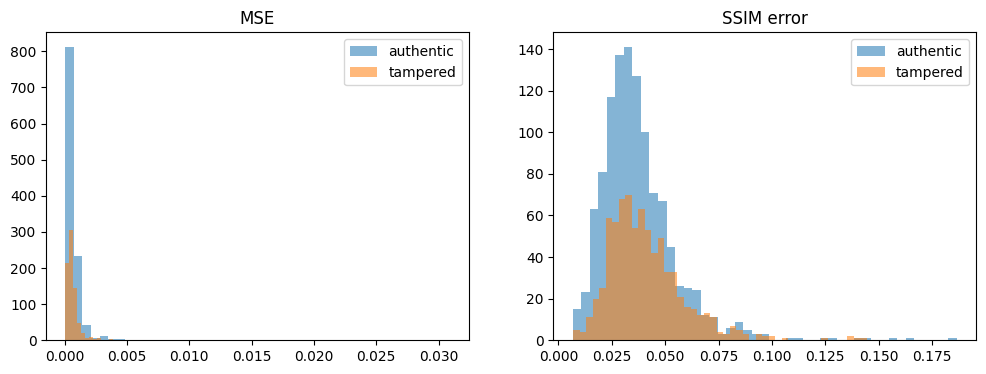

In [7]:
per=pd.read_csv(PROJECT_ROOT/'results'/'vae_v5_final_test_per_image_metrics.csv'); display(per.groupby('class_name')[['mse','psnr','ssim']].agg(['mean','median','std']))
fig,axes=plt.subplots(1,2,figsize=(12,4))
for name,g in per.groupby('class_name'): axes[0].hist(g.mse,bins=45,alpha=.55,label=name); axes[1].hist(1-g.ssim,bins=45,alpha=.55,label=name)
axes[0].set_title('MSE'); axes[1].set_title('SSIM error'); [ax.legend() for ax in axes]; plt.show()

## 8. Synthetic latent samples

Synthetic research outputs—not genuine forensic evidence. Prior-only generation may be weak because the decoder learned strong image skip connections.

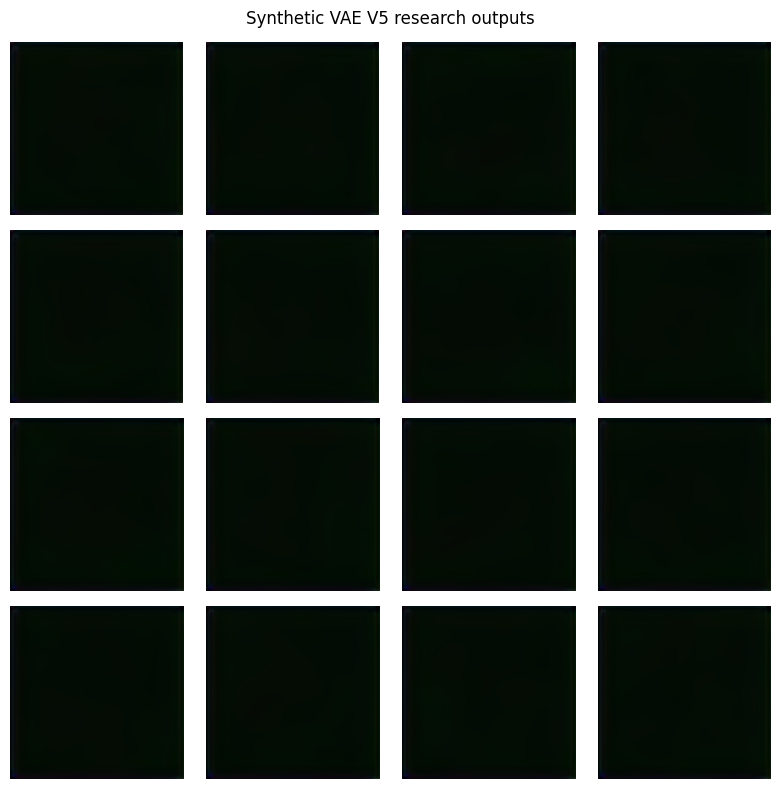

In [8]:
with torch.no_grad(): samples=model.decode(torch.randn(16,256,device=DEVICE))
fig,axes=plt.subplots(4,4,figsize=(8,8))
for ax,img in zip(axes.flat,samples.cpu()): ax.imshow(img.permute(1,2,0).clamp(0,1)); ax.axis('off')
plt.suptitle('Synthetic VAE V5 research outputs'); plt.tight_layout(); plt.show()

## 9. Saved full-test plots

outputs/vae_v5_final/reconstruction_grid.png


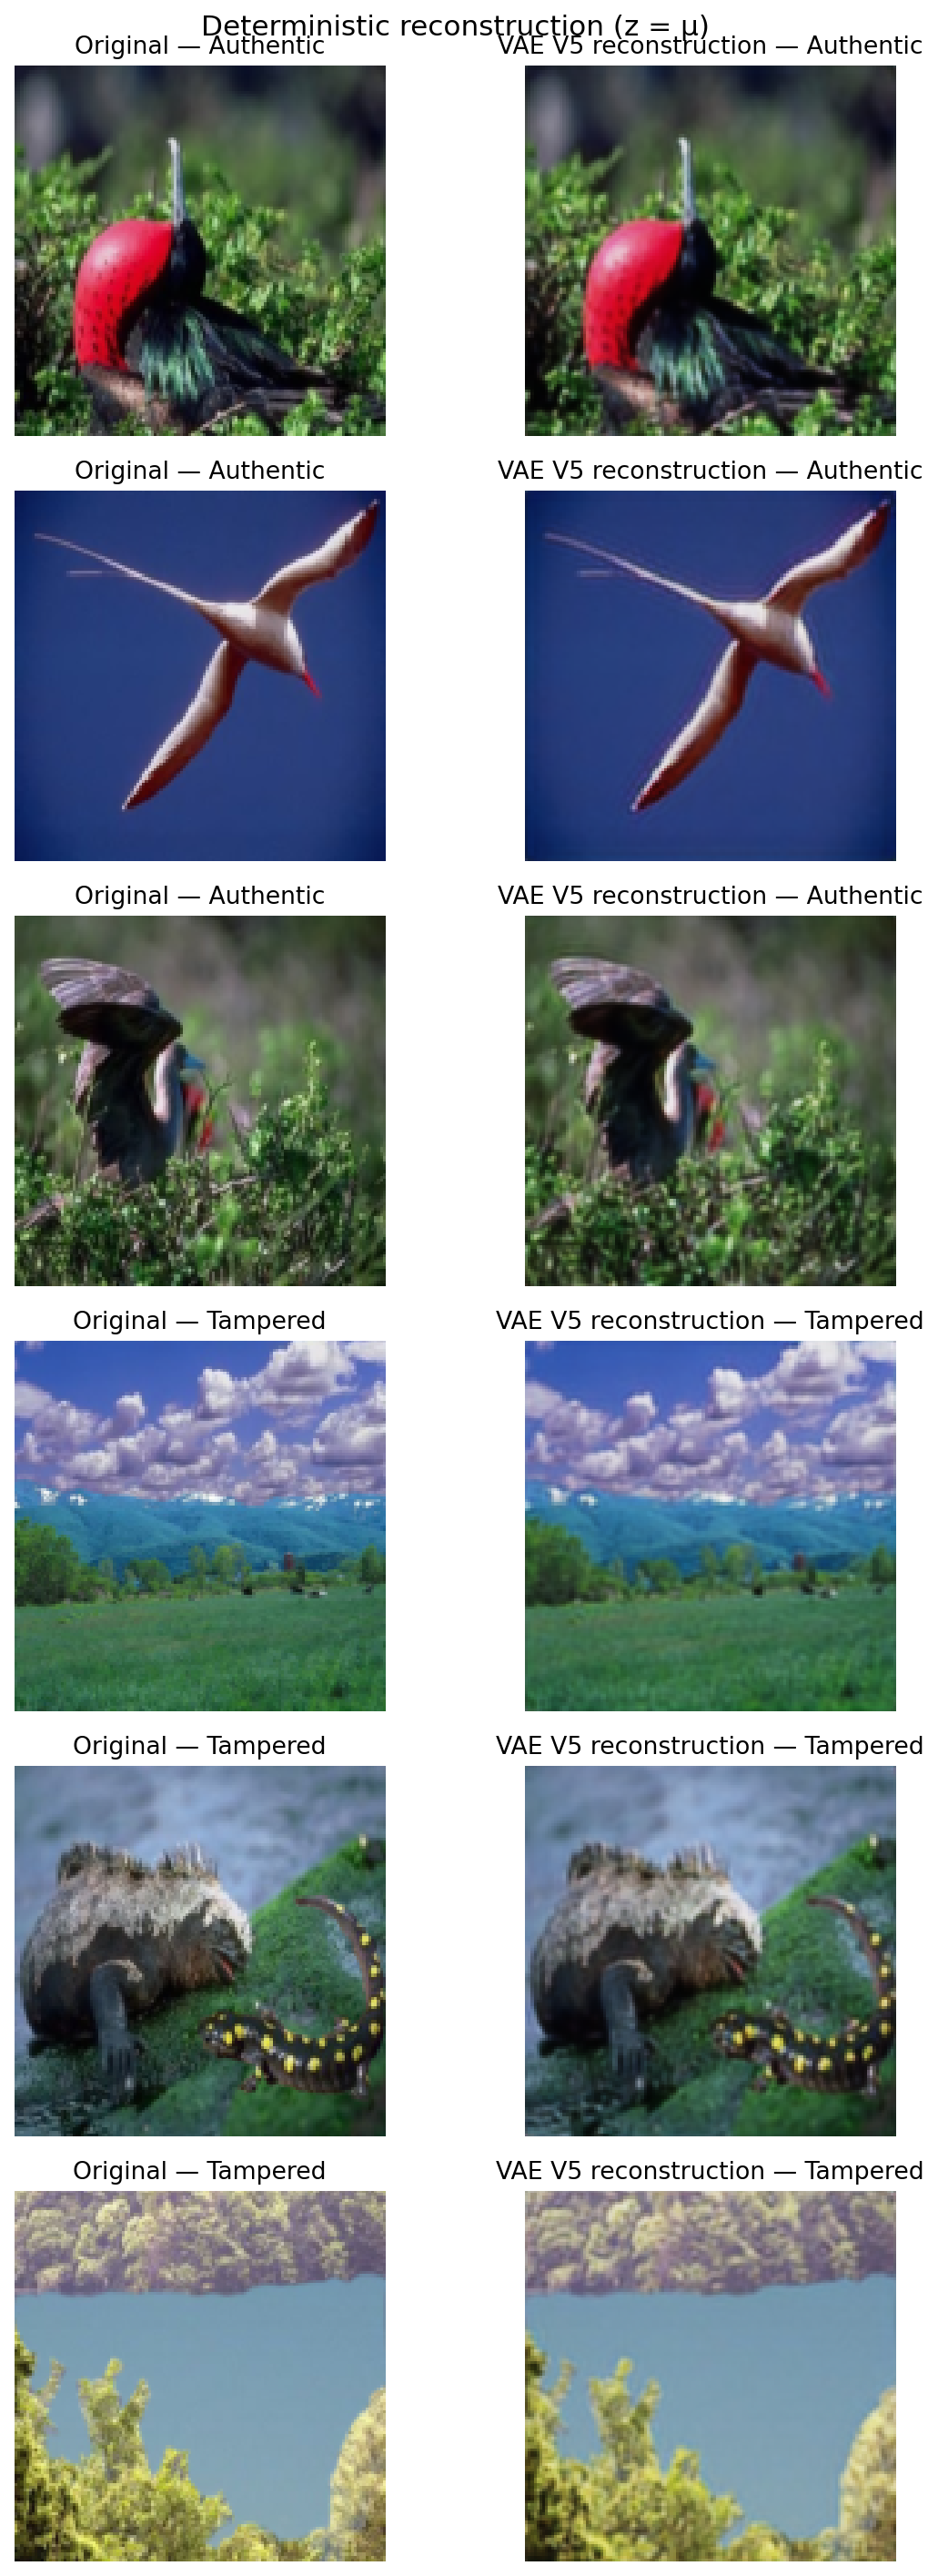

outputs/vae_v5_final/authentic_vs_tampered_error.png


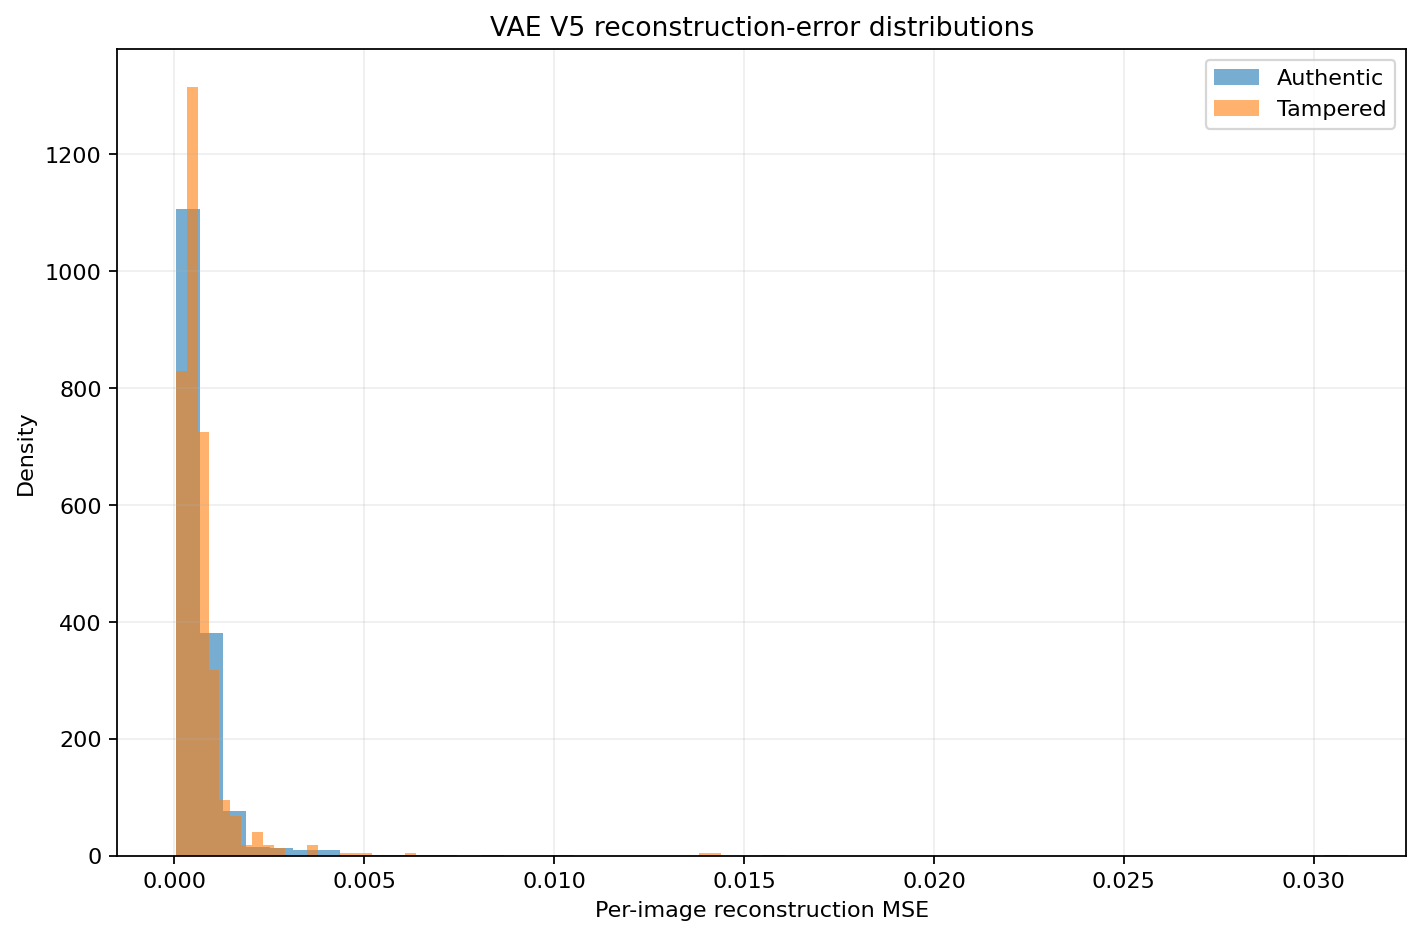

outputs/vae_v5_final/roc_curves.png


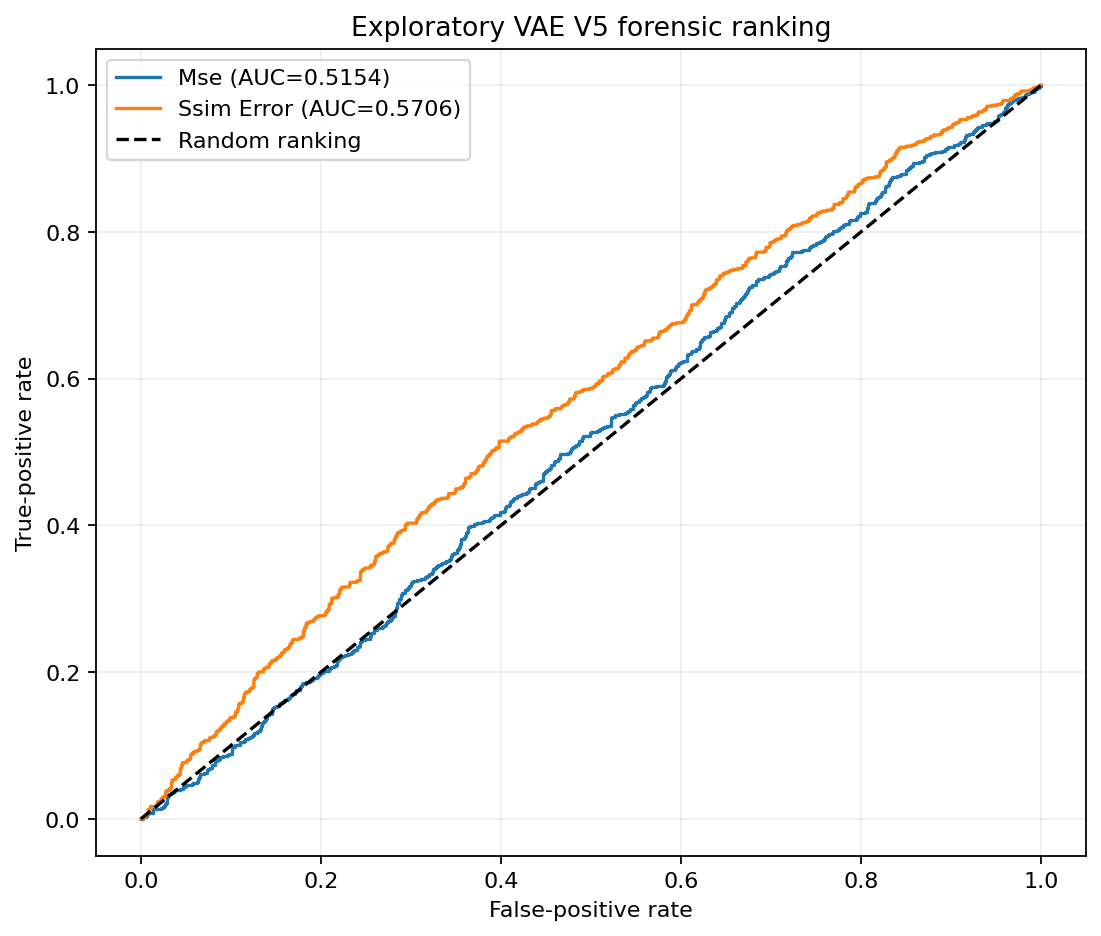

In [9]:
for rel in ('outputs/vae_v5_final/reconstruction_grid.png','outputs/vae_v5_final/authentic_vs_tampered_error.png','outputs/vae_v5_final/roc_curves.png'):
 path=PROJECT_ROOT/rel
 if path.is_file(): print(rel); display(Image.open(path))

## Conclusion

VAE V5 Final gives strong reconstruction but weak MSE-based authentic/tampered separation. It is a reconstruction and exploratory anomaly-analysis module, not a tampering detector.